In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import importlib
import lib.dls as dls

In [2]:
with h5py.File('gencarr_transpose.h5', 'r') as f:
    print(f.keys())
    mean = f['mean'][:]
    data = f['UV'][:2]
    x_grid = f['x_grid'][:]
    y_grid = f['y_grid'][:]
    z_grid = f['z_grid'][:]
    print(f['UV'].shape)
    print( f['mean'].shape)

<KeysViewHDF5 ['UV', 'mean', 'x_grid', 'y_grid', 'z_grid']>
(600, 542, 85, 43, 3)
(542, 85, 43, 3)


In [17]:
data_path = 'gencarr_transpose.h5'
field_name = 'UV'
latent_path = 'latent.h5'
patch_size = 19
num_modes = 10
batch_size = 10

importlib.reload(dls)
# latent_config = dls.gfem_3d_long(data_path, field_name, latent_path, patch_size, num_modes, batch_size)

<module 'lib.dls' from '/mnt/CalebDrive/cmorton/carrier_dls/lib/dls.py'>

In [4]:
import lib.dls_flexible as dls_flexible

In [18]:
importlib.reload(dls)
importlib.reload(dls_flexible)

x, y, z = range(x_grid.shape[0]), range(x_grid.shape[1]), range(x_grid.shape[2])
unif_x, unif_y, unif_z = np.meshgrid(x, y, z, indexing='ij')

with h5py.File('gencarr_transpose.h5', 'r') as f:
    data_mem = {
        "q": data,          # [num_snaps, nx, ny, nz, 3]
        "mean": mean,       # [nx, ny, nz, 3]
        "x_grid": unif_x,
        "y_grid": unif_y,
        "z_grid": unif_z,
    }

latent_config, dof_u, dof_v, dof_w = dls_flexible.gfem_3d_long_flexible(
    data_source=data_mem,
    field_name="q",
    patch_size=patch_size,
    num_modes=num_modes,
    latent_target=None,
    batch_size=batch_size,
)

shape of mode data: (542, 85, 43, 3)
number of snapshots: 2
number of batches: 0
nx: 542
ny: 85
nz: 43
num_vars: 3
Performing modal decomposition to get local modes
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
NYI ----- Data shape: (542, 85, 43), treating as tall for SVD
Modal decomposition done
Constructing local modal matrices
Local modal matrices constructed
Constructing global M GFEM matrices
Prefactorizing M
M prefactorized
Looping through snapshots, solving for dofs


100%|██████████| 1/1 [00:03<00:00,  3.99s/it]

Solved for dofs in 3.99 seconds


In [ ]:
# # %matplotlib widget 
# nskip = 9

# diag_opp_indx = [6, 7, 4, 5, 2, 3, 0, 1]



# # local modal matrix for single element
# i, j, k = 1, 1, 1

# x1 = x_grid[ i   *nskip,  (j-1)*nskip,  k   *nskip]
# x2 = x_grid[ i   *nskip,   j   *nskip,  k   *nskip]
# x3 = x_grid[ i   *nskip,   j   *nskip, (k-1)*nskip]
# x4 = x_grid[ i   *nskip,  (j-1)*nskip, (k-1)*nskip]
# x5 = x_grid[(i-1)*nskip,  (j-1)*nskip,  k   *nskip]
# x6 = x_grid[(i-1)*nskip,   j   *nskip,  k   *nskip]
# x7 = x_grid[(i-1)*nskip,   j   *nskip, (k-1)*nskip]
# x8 = x_grid[(i-1)*nskip,  (j-1)*nskip, (k-1)*nskip]

# y1 = y_grid[ i   *nskip,  (j-1)*nskip,  k   *nskip]
# y2 = y_grid[ i   *nskip,   j   *nskip,  k   *nskip]
# y3 = y_grid[ i   *nskip,   j   *nskip, (k-1)*nskip]
# y4 = y_grid[ i   *nskip,  (j-1)*nskip, (k-1)*nskip]
# y5 = y_grid[(i-1)*nskip,  (j-1)*nskip,  k   *nskip]
# y6 = y_grid[(i-1)*nskip,   j   *nskip,  k   *nskip]
# y7 = y_grid[(i-1)*nskip,   j   *nskip, (k-1)*nskip]
# y8 = y_grid[(i-1)*nskip,  (j-1)*nskip, (k-1)*nskip]

# z1 = z_grid[ i   *nskip,  (j-1)*nskip,  k   *nskip]
# z2 = z_grid[ i   *nskip,   j   *nskip,  k   *nskip]
# z3 = z_grid[ i   *nskip,   j   *nskip, (k-1)*nskip]
# z4 = z_grid[ i   *nskip,  (j-1)*nskip, (k-1)*nskip]
# z5 = z_grid[(i-1)*nskip,  (j-1)*nskip,  k   *nskip]
# z6 = z_grid[(i-1)*nskip,   j   *nskip,  k   *nskip]
# z7 = z_grid[(i-1)*nskip,   j   *nskip, (k-1)*nskip]
# z8 = z_grid[(i-1)*nskip,  (j-1)*nskip, (k-1)*nskip]

# xpt = [x1, x2, x3, x4, x5, x6, x7, x8]
# ypt = [y1, y2, y3, y4, y5, y6, y7, y8]
# zpt = [z1, z2, z3, z4, z5, z6, z7, z8]

# N1 = np.zeros(((nskip+1)**3))
# N2 = np.zeros(((nskip+1)**3))
# N3 = np.zeros(((nskip+1)**3))
# N4 = np.zeros(((nskip+1)**3))
# N5 = np.zeros(((nskip+1)**3))
# N6 = np.zeros(((nskip+1)**3))
# N7 = np.zeros(((nskip+1)**3))
# N8 = np.zeros(((nskip+1)**3))


# for kx in range((nskip+1)):
    
#     for ky in range((nskip+1)):

#         for kz in range((nskip+1)):
            
#             x_val = x_grid[kx, ky, kz]
#             y_val = y_grid[kx, ky, kz]
#             z_val = z_grid[kx, ky, kz]
#             iind = kz*(nskip+1)**2 + ky*(nskip+1) + kx
#             N = dls.FEM_shape_calculator_3D_ortho_gfemlr(x_val, y_val, z_val, xpt, ypt, zpt)
#             N1[iind] = N[0][0]
#             N2[iind] = N[1][0]
#             N3[iind] = N[2][0]
#             N4[iind] = N[3][0]
#             N5[iind] = N[4][0]
#             N6[iind] = N[5][0]
#             N7[iind] = N[6][0]
#             N8[iind] = N[7][0]

# N1 = N1.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N2 = N2.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N3 = N3.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N4 = N4.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N5 = N5.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N6 = N6.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N7 = N7.reshape((nskip+1, nskip+1, nskip+1), order='F')
# N8 = N8.reshape((nskip+1, nskip+1, nskip+1), order='F')

# N_matrix = np.concatenate(( N1[np.newaxis], 
#                             N2[np.newaxis], 
#                             N3[np.newaxis], 
#                             N4[np.newaxis], 
#                             N5[np.newaxis],
#                             N6[np.newaxis], 
#                             N7[np.newaxis], 
#                             N8[np.newaxis]), 
#                             axis=0)
# print(N_matrix.shape)
# mid_pt = patch_size // 2 + 1
# F1 = list(range(0, mid_pt))
# F2 = list(range(mid_pt - 1, patch_size))
# F3 = list(range(0, mid_pt))
# F4 = list(range(mid_pt - 1, patch_size))
# F5 = list(range(0, mid_pt))
# F6 = list(range(mid_pt - 1, patch_size))

# # Create all 8 component index combinations more efficiently
# indices = [
#         (F2, F3, F6), # 1
#         (F2, F4, F6), # 2
#         (F2, F4, F5), # 3
#         (F2, F3, F5), # 4
#         (F1, F3, F6), # 5
#         (F1, F4, F6), # 6
#         (F1, F4, F5), # 7
#         (F1, F3, F5)  # 8
#     ]
# comp_indices = [np.meshgrid(idx[0], idx[1], idx[2], indexing='ij') for idx in indices]

# print(comp_indices[0][0][0,0,-1])
# shape_func = np.zeros((patch_size, patch_size, patch_size))


# for i in range(8):
#     comp_x, comp_y, comp_z = comp_indices[i]
#     # shape_func[comp_x, comp_y, comp_z] = N_matrix[i]
#     shape_func[comp_x, comp_y, comp_z] = N_matrix[diag_opp_indx[i]]

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.view_init(elev=30, azim=45)


# x = range(patch_size)
# [X, Y, Z] = np.meshgrid(x, x, x, indexing='ij')

# # Plot the volume of the shape function N_matrix[0]
# ax.scatter(X, Y, Z, c=shape_func, cmap='viridis')
# ax.set_title('Shape Function N_matrix[0] Visualization')
# #remove axes
# ax.set_xticks([])
# ax.set_yticks([]) 
# ax.set_zticks([])
# ax.set_aspect('equal')



(1000, 88)


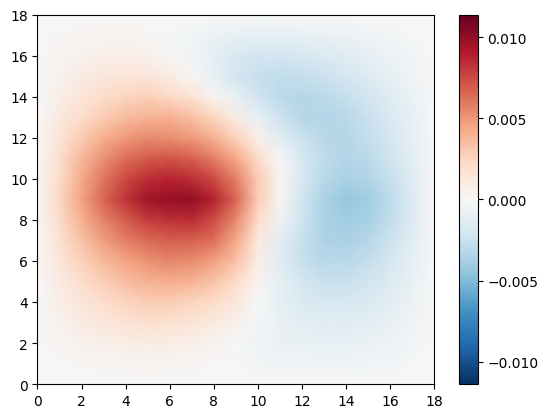

In [19]:
print(latent_config.modemat_local_u.shape)
nskip = patch_size // 2
shape_funcs = latent_config.modemat_local_u
dims = shape_funcs.shape
shape_funcs = shape_funcs.reshape(nskip+1, nskip+1, nskip+1, -1, order='F')
shape_func_reshaped = np.zeros((patch_size, patch_size, patch_size, num_modes+1), dtype=shape_funcs.dtype)
mid_pt = patch_size // 2 + 1

F1 = list(range(0, mid_pt))
F2 = list(range(mid_pt - 1, patch_size))
F3 = list(range(0, mid_pt))
F4 = list(range(mid_pt - 1, patch_size))
F5 = list(range(0, mid_pt))
F6 = list(range(mid_pt - 1, patch_size))

# Create all 8 component index combinations more efficiently
indices = [
        (F2, F3, F6), # 1
        (F2, F4, F6), # 2
        (F2, F4, F5), # 3
        (F2, F3, F5), # 4
        (F1, F3, F6), # 5
        (F1, F4, F6), # 6
        (F1, F4, F5), # 7
        (F1, F3, F5)  # 8
    ]

diag_opp_indx = [6, 7, 4, 5, 2, 3, 0, 1]
opp_indices = [indices[diag_opp_indx[i]] for i in range(8)]

comp_indices = [np.meshgrid(idx[0], idx[1], idx[2], indexing='ij') for idx in opp_indices]

for i in range(num_modes + 1):
    for j, (cx, cy, cz) in enumerate(comp_indices):
        shape_func_reshaped[cx, cy, cz, i] = shape_funcs[..., i + j * (num_modes + 1)]

mode_num = 2
vmax = np.max(np.abs(shape_func_reshaped[..., mode_num]))
plt.pcolormesh(shape_func_reshaped[mid_pt,:, :, mode_num], shading='gouraud', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar()

In [9]:
import lib.generate_weights_grid as generate_weights_grid
importlib.reload(generate_weights_grid)
weights = generate_weights_grid.generate_weights_grid(x_grid, y_grid, z_grid)

In [20]:
importlib.reload(dls)
importlib.reload(dls_flexible)
Q_rec = dls_flexible.gfem_recon_long_3D_flexible(
    rec_target=None,
    config=latent_config,
    dof_u=dof_u,
    dof_v=dof_v,
    dof_w=dof_w,
    batch_size=2,
)

nx_t, ny_t, nz_t = latent_config.nx_t, latent_config.ny_t, latent_config.nz_t

print("Q_rec shape:", Q_rec.shape)
print("weights shape:", weights.shape)
Q_rec_weighted = Q_rec * weights[np.newaxis, :nx_t, :ny_t, :nz_t, np.newaxis]

Processing batch 1/1, batch size: 2

, processed in 0.43s
Total reconstruction time not with saving to disk: 493.66s

Q_rec shape: (2, 541, 82, 37, 3)
weights shape: (542, 85, 43)


(2, 541, 82, 37, 3)


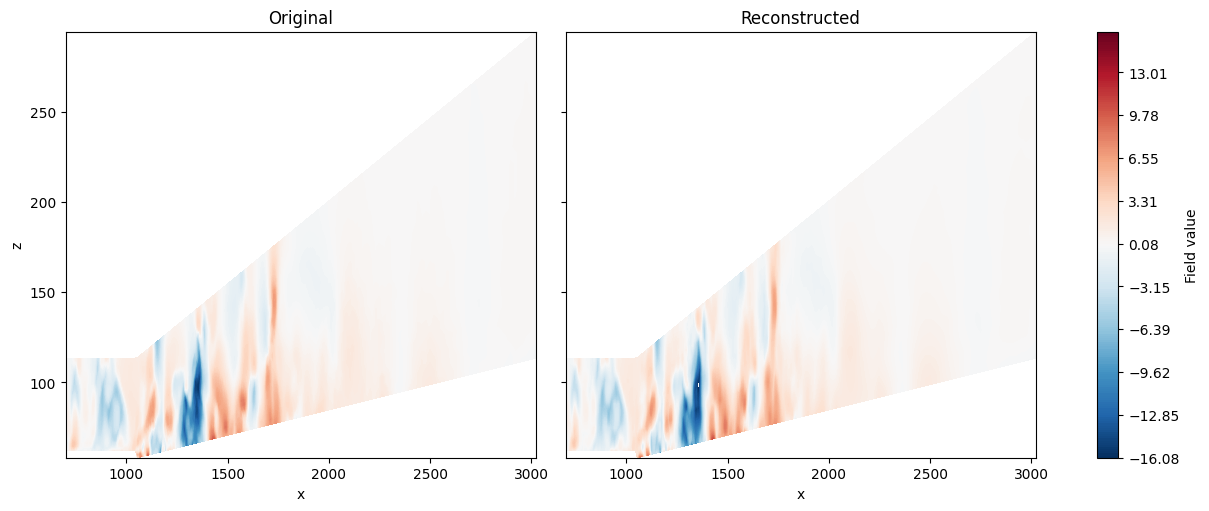

In [21]:
print(Q_rec.shape)

nx_t, ny_t, nz_t = latent_config.nx_t, latent_config.ny_t, latent_config.nz_t
x_trunc = x_grid[:nx_t, :ny_t, :nz_t]
y_trunc = y_grid[:nx_t, :ny_t, :nz_t]
z_trunc = z_grid[:nx_t, :ny_t, :nz_t]

snap_idx = 1
comp_idx = 0   # 0:u, 1:v, 2:w
y_idx = min(18, ny_t - 1)

q_true = data[snap_idx, :nx_t, :ny_t, :nz_t, comp_idx] - mean[:nx_t, :ny_t, :nz_t, comp_idx]
q_rec = Q_rec[snap_idx, :, :, :, comp_idx]

true_slice = q_true[:, y_idx, :]
rec_slice = q_rec[:, y_idx, :]

absmax = np.max(np.abs((true_slice)))
levels = np.linspace(-absmax, absmax, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

c0 = ax[0].contourf(
    x_trunc[:, y_idx, :], z_trunc[:, y_idx, :], true_slice,
    levels=levels, cmap='RdBu_r'
)
ax[0].set_title("Original")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")

c1 = ax[1].contourf(
    x_trunc[:, y_idx, :], z_trunc[:, y_idx, :], rec_slice,
    levels=levels, cmap='RdBu_r'
)
ax[1].set_title("Reconstructed")
ax[1].set_xlabel("x")

fig.colorbar(c1, ax=ax, label="Field value")
plt.show()

2026-04-28 13:17:20.801 ( 264.692s) [    7FE4E98BD080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_184439/2827618847.py:29: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


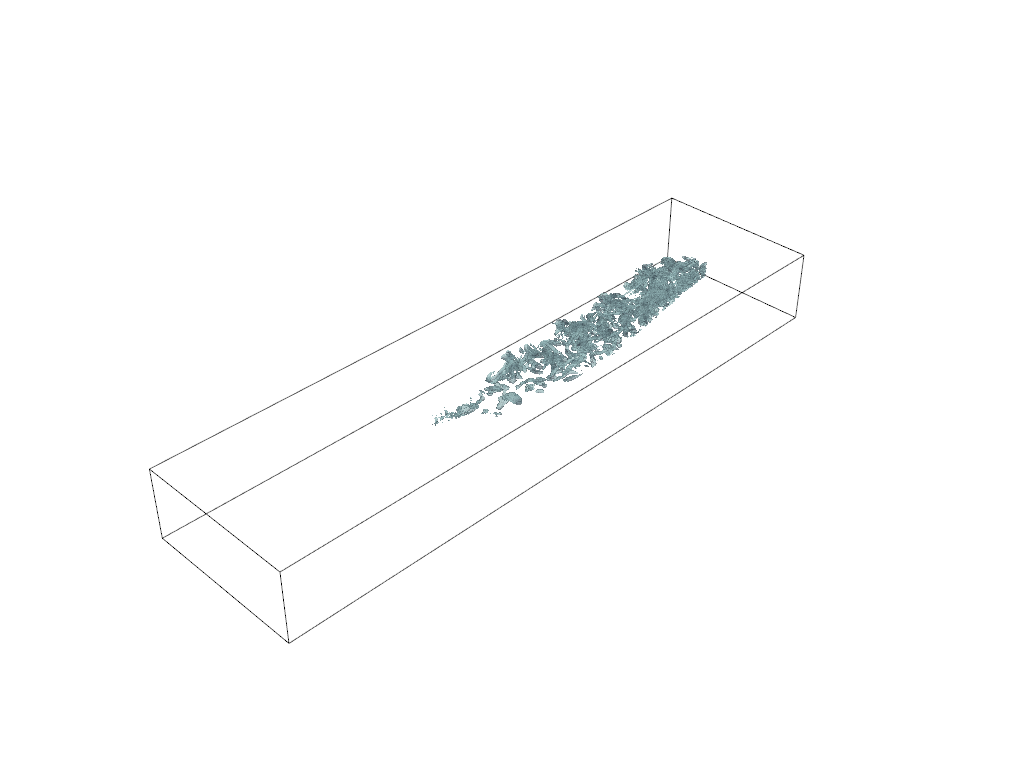

/tmp/ipykernel_184439/2827618847.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


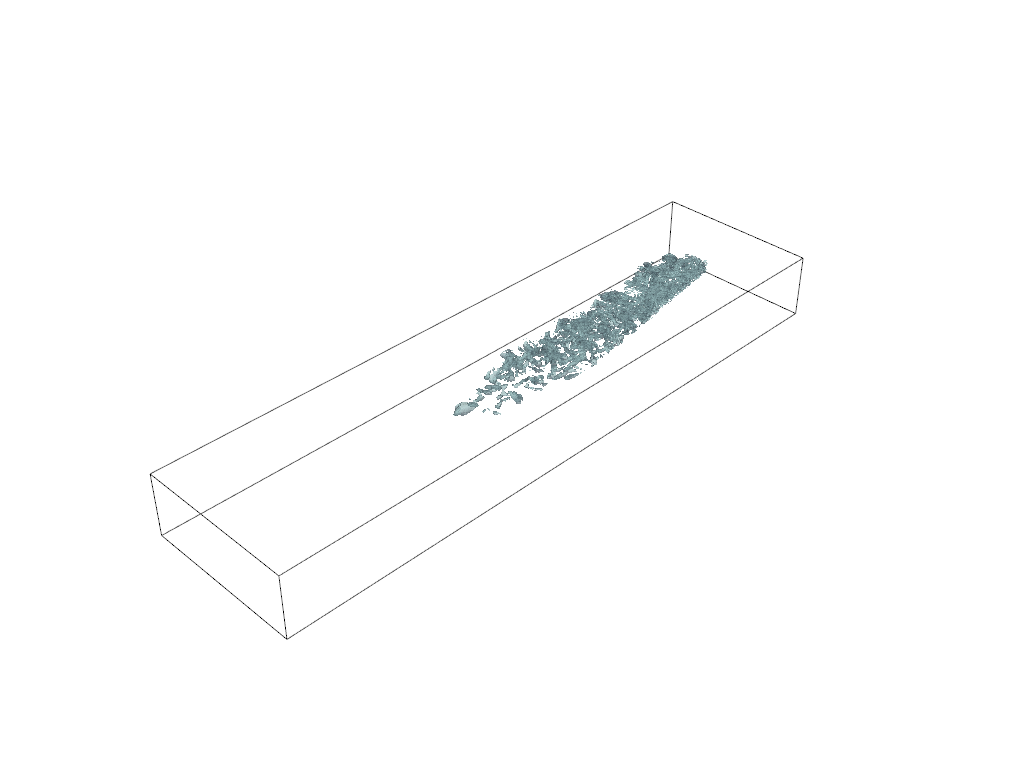

In [23]:
# 1. Create a grid and add velocity data
grid = pv.StructuredGrid(x_grid, y_grid, z_grid)
# PyVista point data must be sized as (n_points,) or (n_points, 3)

grid['velocity'] = data[0].reshape(-1, 3, order='F')

# 2. Compute the velocity gradient tensor
# This returns a (N, 9) array of derivatives [dudx, dudy, dudz, dvdx, ...]
grad = grid.compute_derivative(scalars='velocity', gradient=True)
g = grad['gradient'].reshape(-1, 3, 3)

# 3. Calculate Q-criterion
# S = 0.5 * (g + g.T), Omega = 0.5 * (g - g.T)
S = 0.5 * (g + g.transpose(0, 2, 1))
Omega = 0.5 * (g - g.transpose(0, 2, 1))

# Q = 0.5 * (||Omega||^2 - ||S||^2)
# Using Frobenius norm: sum of squares of components
q_val = 0.5 * (np.sum(Omega**2, axis=(1, 2)) - np.sum(S**2, axis=(1, 2)))
grid['Q-criterion'] = q_val

# 4. Plot Isosurface
# Choose a small positive value for Q to visualize the vortex cores
contour = grid.contour(isosurfaces=[0.01], scalars='Q-criterion')

pl = pv.Plotter()
pl.add_mesh(contour, color='lightblue', opacity=0.7)
pl.add_mesh(grid.outline(), color='black')
pl.show()

# plot q criterion isosurface of reconstructed field
grid_rec = pv.StructuredGrid(x_trunc, y_trunc, z_trunc)
grid_rec['velocity'] = Q_rec[0].reshape(-1, 3, order='F')
# 2. Compute the velocity gradient tensor
# This returns a (N, 9) array of derivatives [dudx, dudy, dudz, dvdx, ...]
grad = grid_rec.compute_derivative(scalars='velocity', gradient=True)
g = grad['gradient'].reshape(-1, 3, 3)

# 3. Calculate Q-criterion
# S = 0.5 * (g + g.T), Omega = 0.5 * (g - g.T)
S = 0.5 * (g + g.transpose(0, 2, 1))
Omega = 0.5 * (g - g.transpose(0, 2, 1))

# Q = 0.5 * (||Omega||^2 - ||S||^2)
# Using Frobenius norm: sum of squares of components
q_val = 0.5 * (np.sum(Omega**2, axis=(1, 2)) - np.sum(S**2, axis=(1, 2)))
grid_rec['Q-criterion'] = q_val

# 4. Plot Isosurface
# Choose a small positive value for Q to visualize the vortex cores
contour = grid_rec.contour(isosurfaces=[0.01], scalars='Q-criterion')

pl = pv.Plotter()
pl.add_mesh(contour, color='lightblue', opacity=0.7)
pl.add_mesh(grid_rec.outline(), color='black')
pl.show()

In [22]:
# computer error between reconstructed and original snapshots
Q_true = data[:,:nx_t, :ny_t, :nz_t] - mean[:nx_t, :ny_t, :nz_t]
L2_error = np.linalg.norm(Q_rec - Q_true) / np.linalg.norm(Q_true)
print(f"% L2 error: {100*L2_error:.4f}")

% L2 error: 16.0978
